# Seasonal EDA
**KrishiDrishti** | Phase 3

How do performance, environment, resources, economics and risk vary across seasons?

> Status: skeleton only. No analysis has been run yet.

In [ ]:
# Setup: make the project root importable, then load the shared helpers
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
#"If I'm currently inside the notebooks folder, go one level up and call that the project root. 
#Otherwise, treat my current location as the project root."
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.data_loader import load_raw
from src.io_utils import save_figure, save_table

pd.set_option("display.max_columns", 50)
df_raw = load_raw()          # untouched raw data
print(df_raw.shape)

(4000, 28)


In [2]:
df = df_raw.copy()
print(df.shape)
df.head()

(4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
season_counts = df["Season"].value_counts()
print(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [6]:
season_pct = df["Season"].value_counts(normalize=True) * 100
print(season_pct)

Season
Kharif    44.475
Rabi      40.675
Zaid      14.850
Name: proportion, dtype: float64


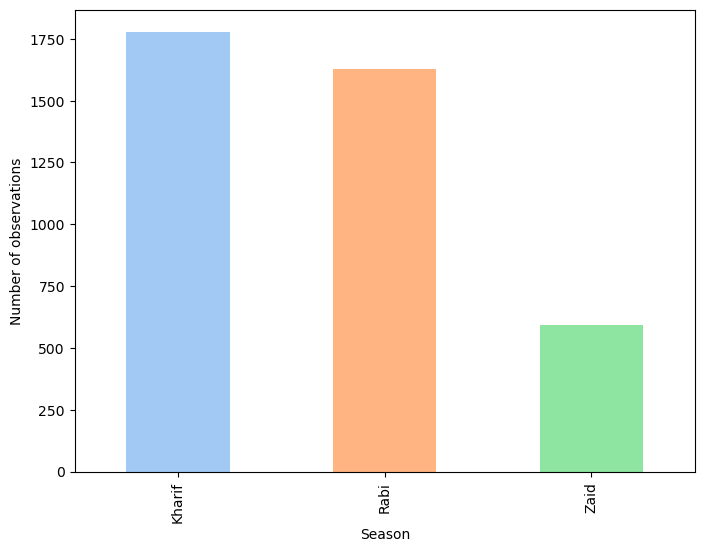

In [7]:
plt.figure(figsize=(8, 6))
title="Distribution of Seasons in the Dataset"
season_counts.plot(kind="bar",color=sns.color_palette("pastel"))
plt.xlabel("Season")
plt.ylabel("Number of observations");
plt.show()

In [10]:
season_yield= df.groupby("Season")["Yield_Tonnes_Ha"].mean()
print(season_yield)

Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


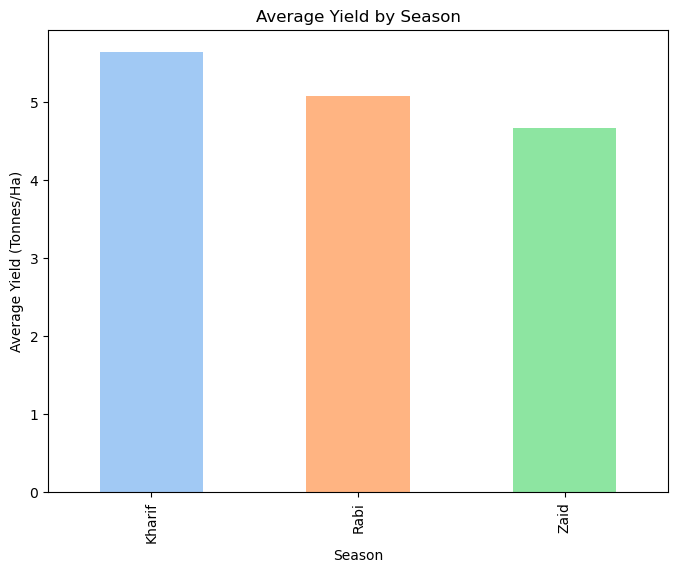

In [11]:
plt.figure(figsize=(8, 6))
season_yield.plot(kind="bar",color=sns.color_palette("pastel"))
plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.show()

In [12]:
crop_season = pd.crosstab(df["Crop"], df["Season"])
print(crop_season)

Season     Kharif  Rabi  Zaid
Crop                         
Chilli        185   163    64
Cotton        215   201    92
Groundnut     193   177    54
Maize         234   233    84
Pulses        221   213    62
Rice          314   274   102
Sugarcane     125   129    51
Wheat         292   237    85


In [13]:
crop_season_pct = pd.crosstab(
    df["Crop"],
    df["Season"],
    normalize="index"
) * 100

print(crop_season_pct.round(2))

Season     Kharif   Rabi   Zaid
Crop                           
Chilli      44.90  39.56  15.53
Cotton      42.32  39.57  18.11
Groundnut   45.52  41.75  12.74
Maize       42.47  42.29  15.25
Pulses      44.56  42.94  12.50
Rice        45.51  39.71  14.78
Sugarcane   40.98  42.30  16.72
Wheat       47.56  38.60  13.84


In [14]:
crop_season_yield = df.groupby(
    ["Crop", "Season"]
)["Yield_Tonnes_Ha"].mean().unstack()

print(crop_season_yield.round(2))

Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.46   1.18
Cotton       1.37   1.19   0.95
Groundnut    1.48   1.22   1.04
Maize        2.97   2.61   2.30
Pulses       1.04   0.87   0.65
Rice         2.71   2.33   1.90
Sugarcane   53.46  43.94  38.42
Wheat        2.26   2.06   1.75


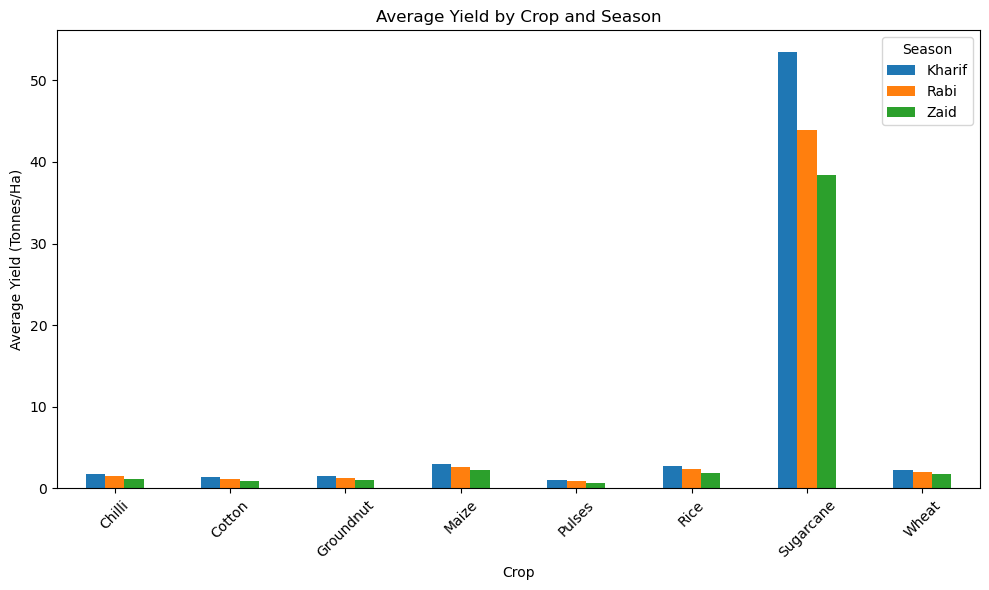

In [15]:
crop_season_yield.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

In [19]:
season_yield_change = pd.DataFrame({
    "Kharif_to_Zaid_Drop": (
        (crop_season_yield["Kharif"] - crop_season_yield["Zaid"])
        / crop_season_yield["Kharif"]
    ) * 100
})

print(season_yield_change.round(2))

           Kharif_to_Zaid_Drop
Crop                          
Chilli                   31.98
Cotton                   30.68
Groundnut                30.05
Maize                    22.55
Pulses                   37.06
Rice                     29.81
Sugarcane                28.12
Wheat                    22.47


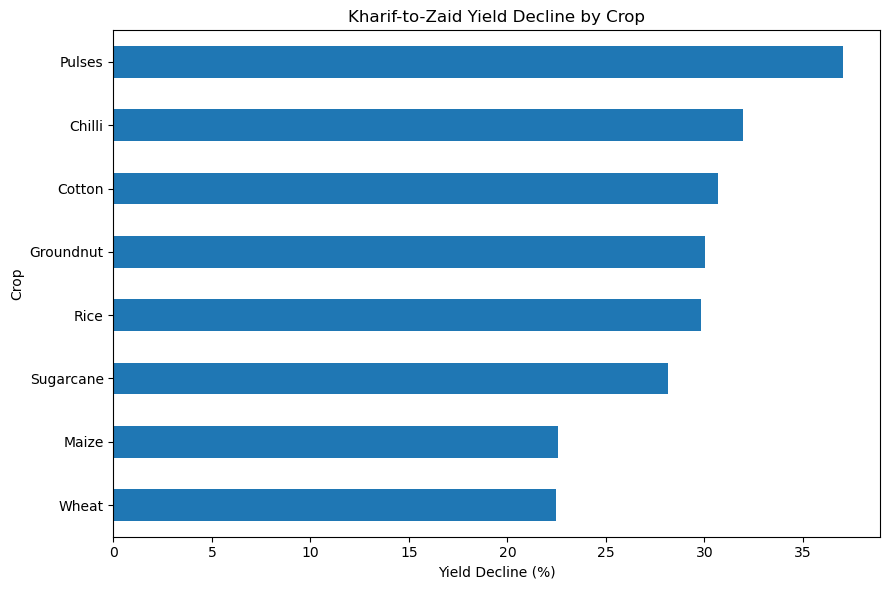

In [20]:
plt.figure(figsize=(9, 6))

season_yield_change["Kharif_to_Zaid_Drop"].sort_values().plot(
    kind="barh"
)

plt.title("Kharif-to-Zaid Yield Decline by Crop")
plt.xlabel("Yield Decline (%)")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [21]:
season_rainfall = df.groupby("Season")["Rainfall_mm"].mean()

print(season_rainfall.round(2))

Season
Kharif    852.08
Rabi      436.00
Zaid      299.42
Name: Rainfall_mm, dtype: float64


In [22]:
rainfall_yield_corr = df[
    ["Rainfall_mm", "Yield_Tonnes_Ha"]
].corr()

print(rainfall_yield_corr.round(3))

                 Rainfall_mm  Yield_Tonnes_Ha
Rainfall_mm            1.000            0.031
Yield_Tonnes_Ha        0.031            1.000


In [23]:
season_temperature = df.groupby("Season")["Avg_Temperature_C"].mean()

print(season_temperature.round(2))

Season
Kharif    28.45
Rabi      23.49
Zaid      31.04
Name: Avg_Temperature_C, dtype: float64


In [24]:
season_environment = pd.DataFrame({
    "Rainfall_mm": season_rainfall,
    "Temperature_C": season_temperature,
    "Yield_Tonnes_Ha": season_yield
})

print(season_environment.round(2))

        Rainfall_mm  Temperature_C  Yield_Tonnes_Ha
Season                                             
Kharif       852.08          28.45             5.64
Rabi         436.00          23.49             5.08
Zaid         299.42          31.04             4.67


In [25]:
season_humidity = df.groupby("Season")["Humidity_pct"].mean()
season_sunlight = df.groupby("Season")["Sunlight_Hours_Day"].mean()
season_soil_moisture = df.groupby("Season")["Soil_Moisture_pct"].mean()

print("Humidity:")
print(season_humidity.round(2))

print("\nSunlight:")
print(season_sunlight.round(2))

print("\nSoil Moisture:")
print(season_soil_moisture.round(2))

Humidity:
Season
Kharif    71.81
Rabi      57.89
Zaid      52.01
Name: Humidity_pct, dtype: float64

Sunlight:
Season
Kharif    6.79
Rabi      7.59
Zaid      8.18
Name: Sunlight_Hours_Day, dtype: float64

Soil Moisture:
Season
Kharif    31.20
Rabi      24.05
Zaid      19.17
Name: Soil_Moisture_pct, dtype: float64


In [26]:
season_environment = pd.DataFrame({
    "Rainfall_mm": season_rainfall,
    "Temperature_C": season_temperature,
    "Humidity_pct": season_humidity,
    "Sunlight_Hours_Day": season_sunlight,
    "Soil_Moisture_pct": season_soil_moisture,
    "Yield_Tonnes_Ha": season_yield
})

print(season_environment.round(2))

        Rainfall_mm  Temperature_C  Humidity_pct  Sunlight_Hours_Day  \
Season                                                                 
Kharif       852.08          28.45         71.81                6.79   
Rabi         436.00          23.49         57.89                7.59   
Zaid         299.42          31.04         52.01                8.18   

        Soil_Moisture_pct  Yield_Tonnes_Ha  
Season                                      
Kharif              31.20             5.64  
Rabi                24.05             5.08  
Zaid                19.17             4.67  


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Yield_Tonnes_Ha
Season,,,,,,
Kharif,852.08,28.45,71.81,6.79,31.20,5.64
Rabi,436.00,23.49,57.89,7.59,24.05,5.08
Zaid,299.42,31.04,52.01,8.18,19.17,4.67


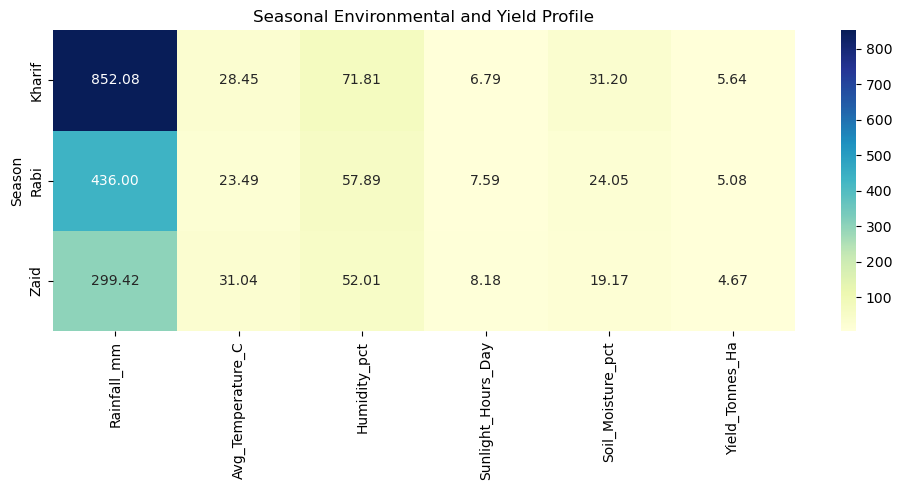

In [28]:
season_environment = df.groupby("Season").agg({
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Humidity_pct": "mean",
    "Sunlight_Hours_Day": "mean",
    "Soil_Moisture_pct": "mean",
    "Yield_Tonnes_Ha": "mean"
}).round(2)

display(season_environment)

plt.figure(figsize=(10, 5))
sns.heatmap(season_environment, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Seasonal Environmental and Yield Profile")
plt.tight_layout()
plt.show()

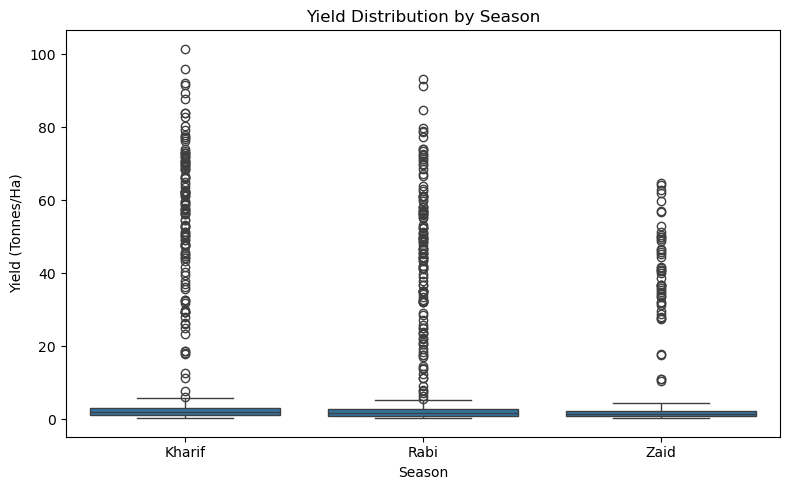

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")

plt.title("Yield Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

Irrigation_Method
Drip         6.62
Sprinkler    5.19
Flood        4.90
Rainfed      4.61
Name: Yield_Tonnes_Ha, dtype: float64


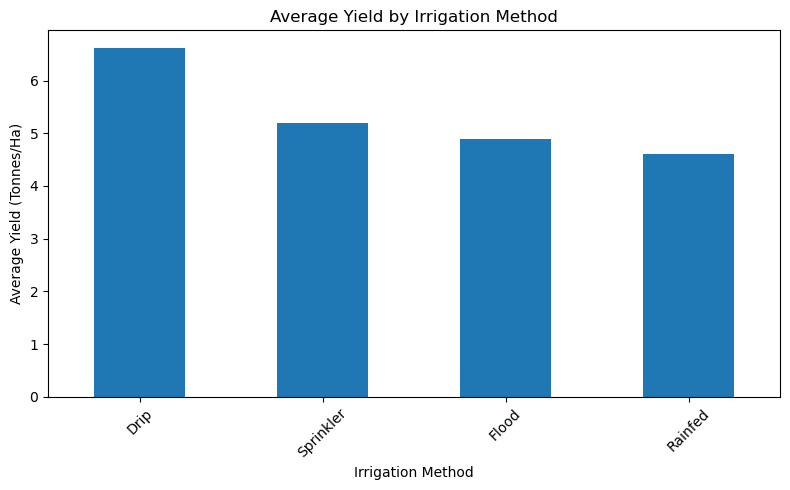

In [30]:
irrigation_yield = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print(irrigation_yield.round(2))

plt.figure(figsize=(8, 5))
irrigation_yield.plot(kind="bar")
plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

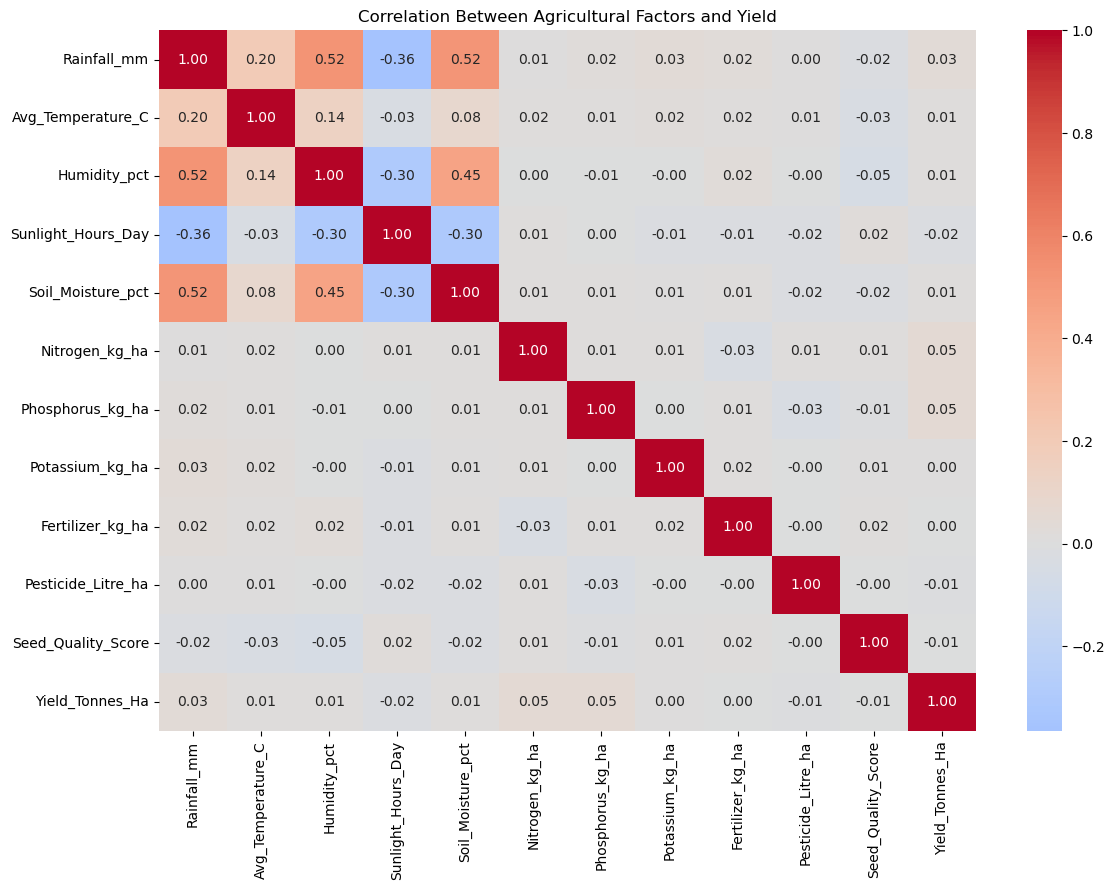

In [31]:
cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Yield_Tonnes_Ha"
]

corr = df[cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Agricultural Factors and Yield")
plt.tight_layout()
plt.show()

,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,
Kharif,5.64,710719.06,531804.41,178914.65,6102.20,5.89
Rabi,5.08,601526.05,513836.58,87689.47,5846.99,5.19
Zaid,4.67,519171.90,543976.73,-24804.82,6419.89,4.41


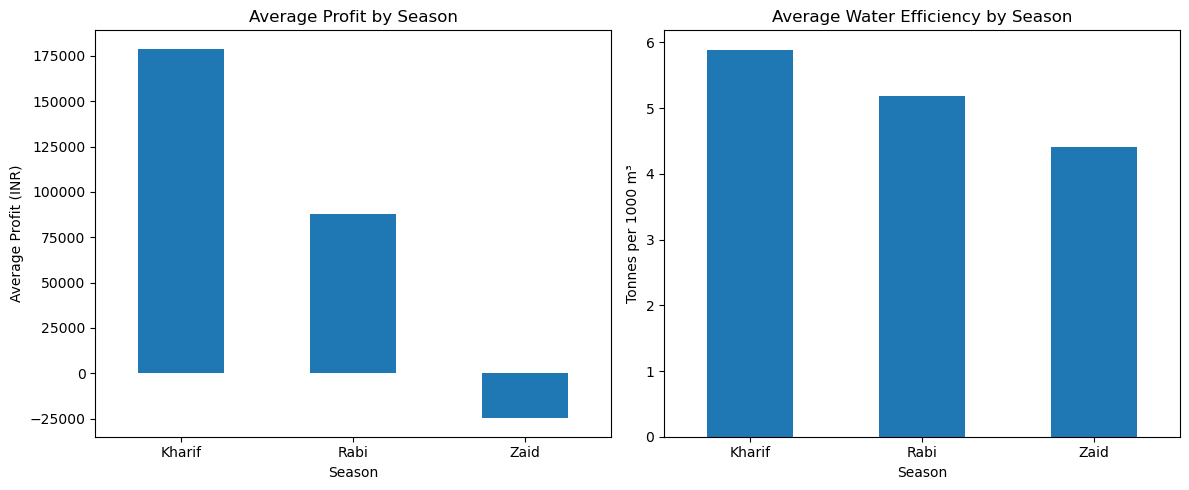

In [34]:
season_economics = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
}).round(2)

display(season_economics)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

season_economics["Profit_INR"].plot(
    kind="bar",
    ax=axes[0],
    title="Average Profit by Season"
)

axes[0].set_xlabel("Season")
axes[0].set_ylabel("Average Profit (INR)")
axes[0].tick_params(axis="x", rotation=0)

season_economics["Water_Efficiency_t_per_1000m3"].plot(
    kind="bar",
    ax=axes[1],
    title="Average Water Efficiency by Season"
)

axes[1].set_xlabel("Season")
axes[1].set_ylabel("Tonnes per 1000 m³")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# Seasonal EDA — Analysis Findings

## Finding 1 — Dataset Seasonal Composition

**Question:** How are observations distributed across seasons?

### Result

| Season | Observations | Share |
|---|---:|---:|
| Kharif | 1,779 | 44.48% |
| Rabi | 1,627 | 40.68% |
| Zaid | 594 | 14.85% |

### Interpretation

Kharif and Rabi account for most observations, while Zaid has substantially fewer observations.

**Important limitation:** Zaid's smaller sample means estimates for Zaid may have greater sampling uncertainty.

---

## Finding 2 — Overall Seasonal Yield

**Question:** Does average yield differ across seasons?

### Result

| Season | Avg. Yield (t/ha) |
|---|---:|
| Kharif | 5.644 |
| Rabi | 5.080 |
| Zaid | 4.666 |

### Observation

Kharif has the highest average yield and Zaid the lowest.

### Interpretation

There is a clear descriptive seasonal difference in average yield.

> **Caution:** This does not establish that season itself causes higher or lower yield.

---

## Finding 3 — Crop Distribution Across Seasons

**Question:** Are crops concentrated in particular seasons?

### Result

Every one of the 8 crops occurs in all 3 seasons, with broadly similar seasonal distributions.

Examples:

- **Chilli:** 44.90% Kharif, 39.56% Rabi, 15.53% Zaid
- **Rice:** 45.51% Kharif, 39.71% Rabi, 14.78% Zaid
- **Wheat:** 47.56% Kharif, 38.60% Rabi, 13.84% Zaid

### Interpretation

The dataset does not show extreme crop-season concentration.

This is important because it makes the later **crop × season yield comparison** more informative.

---

## Finding 4 — Yield Within Each Crop

**Question:** Does the seasonal yield pattern remain when comparing the same crop?

### Result

Every one of the 8 crops follows:

> **Kharif > Rabi > Zaid**

Examples:

| Crop | Kharif | Rabi | Zaid |
|---|---:|---:|---:|
| Chilli | 1.73 | 1.46 | 1.18 |
| Maize | 2.97 | 2.61 | 2.30 |
| Rice | 2.71 | 2.33 | 1.90 |
| Wheat | 2.26 | 2.06 | 1.75 |
| Sugarcane | 53.46 | 43.94 | 38.42 |

### Interpretation

The seasonal yield pattern is not limited to the overall crop composition; it is also observed within every crop in this dataset.

**Caution:** This is still descriptive, not causal.

---

## Finding 5 — Kharif → Zaid Yield Decline

**Question:** How large is the seasonal difference for each crop?

### Result

| Crop | Kharif → Zaid Decline |
|---|---:|
| Chilli | 31.98% |
| Cotton | 30.68% |
| Groundnut | 30.05% |
| Maize | 22.55% |
| Pulses | 37.06% |
| Rice | 29.81% |
| Sugarcane | 28.12% |
| Wheat | 22.47% |

### Interpretation

The decline varies considerably across crops, from approximately **22.5% to 37.1%**.

Pulses show the largest observed relative decline, while Wheat shows the smallest.

> **Caution:** This is not a ranking of which crop is better. It represents only the magnitude of the observed seasonal yield difference.

---

## Finding 6 — Rainfall and Seasonal Yield

**Question:** Does rainfall follow the same seasonal pattern as yield?

### Result

| Season | Avg. Rainfall (mm) | Avg. Yield (t/ha) |
|---|---:|---:|
| Kharif | 852.08 | 5.64 |
| Rabi | 436.00 | 5.08 |
| Zaid | 299.42 | 4.67 |

### Observation

Both rainfall and average yield decrease in the following order:

> **Kharif → Rabi → Zaid**

However, seasonal averages alone do not establish a direct relationship between rainfall and yield.

Therefore, a farm-level correlation analysis was performed.

---

## Finding 7 — Farm-Level Rainfall × Yield Relationship

**Question:** Are farms receiving more rainfall also showing higher yields?

### Result

**Pearson correlation = 0.031**

### Interpretation

The relationship is extremely weak and close to zero at the individual-observation level.

### Important Insight

Although seasons with higher average rainfall also have higher average yields, **rainfall alone does not explain the farm-level variation in yield in this dataset**.

This demonstrates why **aggregate seasonal comparisons and individual-level relationships can tell different stories**.

> **Key distinction:** The seasonal averages show an association between rainfall and yield across seasons, while the farm-level correlation shows almost no linear relationship between the two variables across individual observations.

---

## Finding 8 — Seasonal Temperature

**Question:** How does temperature vary across seasons, and how does it compare with seasonal yield?

### Result

| Season | Avg. Temperature (°C) | Avg. Yield (t/ha) |
|---|---:|---:|
| Kharif | 28.45 | 5.64 |
| Rabi | 23.49 | 5.08 |
| Zaid | 31.04 | 4.67 |

### Observation

Temperature follows a different seasonal pattern from rainfall and yield.

Zaid has the **highest average temperature (31.04°C)** but the **lowest average yield (4.67 t/ha)**.

### Interpretation

The seasonal averages show that temperature and yield do not move together consistently across the three seasons.

This suggests that seasonal yield differences cannot be interpreted using temperature alone.

Other factors such as rainfall, irrigation, soil conditions, crop composition, and farming practices may also contribute to yield variation.

> **Caution:** These are aggregate seasonal comparisons and do not establish that temperature causes changes in yield.

---

## Finding 9 — Seasonal Environmental Profile

**Question:** How do multiple environmental conditions differ across seasons?

### Result

| Season | Rainfall (mm) | Temperature (°C) | Humidity (%) | Sunlight (h/day) | Soil Moisture (%) | Yield (t/ha) |
|---|---:|---:|---:|---:|---:|---:|
| Kharif | 852.08 | 28.45 | 71.81 | 6.79 | 31.20 | 5.64 |
| Rabi | 436.00 | 23.49 | 57.89 | 7.59 | 24.05 | 5.08 |
| Zaid | 299.42 | 31.04 | 52.01 | 8.18 | 19.17 | 4.67 |

### Observation

The three seasons show distinct environmental profiles.

Kharif has the highest rainfall, humidity, and soil moisture, while Zaid has the highest temperature and sunlight but the lowest rainfall, humidity, and soil moisture.

### Interpretation

The seasonal yield differences occur alongside multiple environmental differences rather than a change in a single variable.

Kharif combines higher rainfall, humidity, and soil moisture with the highest observed average yield, whereas Zaid has lower rainfall and soil moisture alongside the lowest observed average yield.

This suggests that seasonal agricultural performance should be examined using **multiple environmental and farming factors together**, rather than attributing yield differences to a single variable.

> **Caution:** These are aggregate seasonal patterns and do not establish causal relationships between individual environmental variables and yield.

---

## Finding 10 — Irrigation Method and Yield

**Question:** Does average yield differ across irrigation methods?

### Result

| Irrigation Method | Avg. Yield (t/ha) |
|---|---:|
| Drip | 6.62 |
| Sprinkler | 5.19 |
| Flood | 4.90 |
| Rainfed | 4.61 |

### Interpretation

Average yield differs across irrigation methods in the dataset.

Drip-irrigated farms show the highest observed average yield, while rainfed farms show the lowest.

> **Caution:** This is a descriptive comparison. The difference does not establish that irrigation method itself causes the observed yield difference, since other farm and environmental characteristics may differ between groups.

---

## Finding 11 — Individual Factor–Yield Correlations

**Question:** Do individual environmental and farming variables show strong linear relationships with yield?

### Result

The Pearson correlations between individual numerical variables and yield are all very weak.

| Variable | Correlation with Yield |
|---|---:|
| Rainfall | 0.03 |
| Temperature | 0.01 |
| Humidity | 0.01 |
| Sunlight | -0.02 |
| Soil Moisture | 0.01 |
| Nitrogen | 0.05 |
| Phosphorus | 0.05 |
| Potassium | 0.00 |
| Fertilizer | 0.00 |
| Pesticide | -0.01 |
| Seed Quality | -0.01 |

### Interpretation

No individual numerical variable shows a strong linear association with yield in this dataset.

This suggests that farm-level yield variation may not be adequately explained by any single numerical factor considered independently.

This provides motivation for examining **multivariate relationships using machine-learning models**, where multiple environmental, agricultural, seasonal, and management variables can be considered simultaneously.

> **Caution:** Weak Pearson correlation does not mean that a variable is unimportant. It only indicates a weak linear relationship when considered individually.

---

## Finding 12 — Yield Distribution Across Seasons

**Question:** Are seasonal yield differences consistent across individual observations?

### Result

The seasonal boxplots show highly right-skewed yield distributions, with many observations extending substantially above the main distribution.

### Observation

All three seasons contain numerous high-yield observations. The main distributions are relatively concentrated at lower yield values, while a smaller number of observations have substantially higher yields.

### Interpretation

The seasonal mean differences should be interpreted alongside the underlying distribution rather than in isolation.

The strong right-skew is partly related to the large difference in yield scale between crops, particularly Sugarcane compared with the other crops.

This reinforces the importance of examining **crop-specific seasonal performance** rather than relying only on overall seasonal averages.

> **Caution:** The boxplot does not by itself establish why these high-yield observations occur. Crop type, farm characteristics, and other factors may contribute to the observed distribution.

---

## Finding 13 — Seasonal Profitability and Water Efficiency

**Question:** Do seasonal differences in agricultural performance translate into differences in profitability and water efficiency?

### Result

| Season | Avg. Yield (t/ha) | Avg. Revenue (INR) | Avg. Cost (INR) | Avg. Profit (INR) | Water Efficiency (t/1,000 m³) |
|---|---:|---:|---:|---:|---:|
| Kharif | 5.64 | 710,719.06 | 531,804.41 | 178,914.65 | 5.89 |
| Rabi | 5.08 | 601,526.05 | 513,836.58 | 87,689.47 | 5.19 |
| Zaid | 4.67 | 519,171.90 | 543,976.73 | -24,804.82 | 4.41 |

### Observation

Kharif has the highest average profit and water efficiency, while Zaid has the lowest.

Notably, Zaid has a positive average yield but a **negative average profit**, because its average cost exceeds its average revenue.

### Interpretation

The results demonstrate that agricultural performance should not be evaluated using yield alone.

Seasonal differences in revenue, production costs, profitability, and water efficiency provide additional dimensions for evaluating farm performance.

> **Caution:** These are descriptive seasonal averages and do not establish that season itself causes differences in profitability or water efficiency.

---

# Current Evidence Summary

| Finding | Main Result |
|---|---|
| Seasonal composition | Kharif 44.48%, Rabi 40.68%, Zaid 14.85% |
| Overall seasonal yield | Kharif > Rabi > Zaid |
| Crop distribution | All 8 crops occur across all 3 seasons |
| Within-crop yield | Kharif > Rabi > Zaid for all 8 crops |
| Kharif → Zaid yield decline | 22.47%–37.06% across crops |
| Seasonal rainfall | Kharif > Rabi > Zaid |
| Farm-level rainfall × yield | Pearson r = 0.031 |
| Seasonal temperature | Zaid has highest temperature but lowest average yield |
| Environmental profile | Seasons differ across rainfall, temperature, humidity, sunlight, and soil moisture |
| Irrigation | Drip farms have highest observed average yield; rainfed lowest |
| Individual factor × yield | All examined Pearson correlations are very weak |
| Yield distribution | Highly right-skewed across seasons |
| Profitability | Kharif highest average profit; Zaid average profit is negative |
| Water efficiency | Kharif 5.89 > Rabi 5.19 > Zaid 4.41 t/1,000 m³ |

---

# Overall EDA Conclusion

The exploratory analysis reveals substantial **seasonal differences in agricultural performance** across environmental conditions, yield, irrigation groups, profitability, and water efficiency.

The most consistent yield pattern is:

> **Kharif > Rabi > Zaid**

and this pattern is observed not only in the overall dataset but also within each of the 8 crops.

However, the analysis also shows that **individual numerical variables have extremely weak Pearson correlations with farm-level yield**. This indicates that yield variation is unlikely to be adequately described by any single numerical factor in isolation.

At the same time, different seasons have distinct combinations of rainfall, temperature, humidity, sunlight, and soil moisture. Irrigation groups also show different observed yield levels.

Therefore, the EDA suggests that agricultural performance is **multifactorial**, making multivariate analysis and machine-learning approaches appropriate for the next stage of the project.

> **Important limitation:** All findings in this notebook are exploratory and descriptive. They identify patterns and associations in the dataset but do not establish causal relationships.